# Explatory Data Analysis

This notebook implements the EDA stage for the BRFSS heart-disease dataset.

#### Goals
- inspect dataset dimensions and target balance
- remove identifiers and survey-administration variables from the first baseline
- detect constant columns
- detect extremely sparse columns (>95% missing)
- record exactly why each column was removed

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Load the data

In [2]:
X_TRAIN_PATH = Path("./dataset/x_train.csv")
Y_TRAIN_PATH = Path("./dataset/y_train.csv")

def load_csv_with_header(path):
    with open(path, "r", newline="") as f:
        reader = csv.reader(f)
        header = np.array(next(reader))
        rows = []
        for row in reader:
            rows.append([
                np.nan if value == "" else float(value)
                for value in row
            ])
    return header, np.asarray(rows, dtype=float)

feature_names, x_train = load_csv_with_header(X_TRAIN_PATH)
target_names, y_data = load_csv_with_header(Y_TRAIN_PATH)

if y_data.shape[1] == 1:
    y_train = y_data[:, 0]
else:
    idx = [i for i, name in enumerate(target_names) if name != "Id"]
    if len(idx) != 1:
        raise ValueError("Could not uniquely identify target column.")
    y_train = y_data[:, idx[0]]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (328135, 322)
y_train shape: (328135,)


### Observations 

The dataset contains a large number of features (322 in total). In the following steps, we identify features that are irrelevant, redundant, or insufficiently informative for our prediction task. These features are then removed to obtain a cleaner and more interpretable dataset.

In [3]:
def find_constant_features(x, names):
    constant = []
    for j in range(x.shape[1]):
        valid = x[:, j][~np.isnan(x[:, j])]
        if len(valid) == 0 or len(np.unique(valid)) <= 1:
            constant.append(names[j])
    return constant

constant_features = find_constant_features(x_train, feature_names)

print("Constant / empty columns:", len(constant_features))
for feature in constant_features:
    print(" -", feature)


Constant / empty columns: 6
 - CTELENUM
 - COLGHOUS
 - STATERES
 - CTELNUM1
 - CELLFON2
 - CCLGHOUS


## 1.2. Dataset overview

Let's inspect the number of observations, columns and class imbalance.

In [4]:
print(f"Observations: {x_train.shape[0]}")
print(f"Columns: {x_train.shape[1]}")

classes, counts = np.unique(y_train, return_counts=True)

print("\nTarget distribution:")
for c, count in zip(classes, counts):
    print(f"class {int(c)}: {count} ({100*count/len(y_train):.2f}%)")


Observations: 328135
Columns: 322

Target distribution:
class -1: 299160 (91.17%)
class 1: 28975 (8.83%)


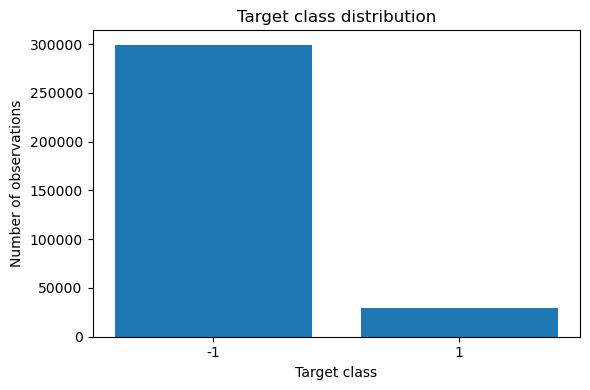

In [5]:
plt.figure(figsize=(6, 4))
labels = [str(int(c)) if float(c).is_integer() else str(c) for c in classes]
plt.bar(labels, counts)
plt.xlabel("Target class")
plt.ylabel("Number of observations")
plt.title("Target class distribution")
plt.tight_layout()
plt.show()


### Observation

The target is imbalanced, so later model evaluation should not rely on accuracy alone. A majority-class classifier can obtain high accuracy without learning a useful decision rule.


## 1.3. Define columns excluded from the first baseline

The BRFSS data mixes health/lifestyle information with identifiers and survey-design metadata. All of these informations were found by reading the [CDC codebook](https://www.cdc.gov/brfss/annual_data/2015/pdf/CODEBOOK15_LLCP.pdf).

For the first baseline, we exclude the variables below because they do not directly describe the respondent's health or lifestyle.


In [6]:
identifier_features = [
    "Id",
    "SEQNO",
    "_PSU",
]

survey_features = [
    "_STATE",
    "FMONTH",
    "IDATE",
    "IMONTH",
    "IDAY",
    "IYEAR",
    "DISPCODE",
    "QSTVER",
    "QSTLANG",
    "_STSTR",
    "_STRWT",
    "_RAWRAKE",
    "_WT2RAKE",
    "_CLLCPWT",
    "_DUALUSE",
    "_DUALCOR",
    "_LLCPWT",
]


## 1.4. Detect constant columns

Columns with no observed variation cannot help distinguish between observations.


In [7]:
def find_constant_features(x, names):
    constant = []
    for j in range(x.shape[1]):
        valid = x[:, j][~np.isnan(x[:, j])]
        if len(valid) == 0 or len(np.unique(valid)) <= 1:
            constant.append(names[j])
    return constant

constant_features = find_constant_features(x_train, feature_names)

print("Constant / empty columns:", len(constant_features))
for feature in constant_features:
    print(" -", feature)


Constant / empty columns: 6
 - CTELENUM
 - COLGHOUS
 - STATERES
 - CTELNUM1
 - CELLFON2
 - CCLGHOUS


The six columns above contain no useful variation in the training data: after ignoring missing values, each of them has at most one unique observed value. Since a constant feature cannot help distinguish between individuals or improve the classifier, these columns can safely be removed from the dataset.


## 1.5. Missing-value analysis

BRFSS contains many conditional questions, so missing values are due to the structure of the survey. For the first baseline, we remove features with more than 95% missing observations.


In [8]:
def compute_missing_rates(x, names):
    return {
        name: np.mean(np.isnan(x[:, j]))
        for j, name in enumerate(names)
    }

missing_rates = compute_missing_rates(x_train, feature_names)

for threshold in [0.10, 0.20, 0.50, 0.80, 0.90, 0.95, 0.99]:
    n = sum(rate >= threshold for rate in missing_rates.values())
    print(f">= {100*threshold:5.1f}% missing: {n} columns")


>=  10.0% missing: 182 columns
>=  20.0% missing: 178 columns
>=  50.0% missing: 147 columns
>=  80.0% missing: 116 columns
>=  90.0% missing: 99 columns
>=  95.0% missing: 68 columns
>=  99.0% missing: 30 columns


In [9]:
MISSING_THRESHOLD = 0.95

sparse_features = [
    name for name in feature_names
    if missing_rates[name] > MISSING_THRESHOLD
]

print(f"Columns with >{100*MISSING_THRESHOLD:.0f}% missing: {len(sparse_features)}")

for feature in sorted(sparse_features, key=lambda f: missing_rates[f], reverse=True):
    print(f"{feature:<15} {100*missing_rates[feature]:6.2f}%")


Columns with >95% missing: 68
COLGHOUS         99.99%
LADULT           99.99%
PCDMDECN         99.95%
ASERVIST         99.93%
ASDRVIST         99.93%
ASNOSLEP         99.90%
ASTHMED3         99.85%
ASINHALR         99.85%
ASYMPTOM         99.85%
ASRCHKUP         99.85%
ASACTLIM         99.85%
ASATTACK         99.85%
STREHAB1         99.84%
PCPSADE1         99.82%
HAREHAB1         99.76%
ASTHMAGE         99.76%
VINOCRE2         99.76%
CCLGHOUS         99.76%
HPVADSHT         99.67%
VIEYEXM2         99.43%
VIMACDG2         99.28%
VICTRCT4         99.28%
VIGLUMA2         99.28%
VIINSUR2         99.28%
VIREDIF3         99.28%
VIPRFVS2         99.28%
VIDFCLT2         99.28%
PCPSARS1         99.20%
PSATIME          99.20%
CDHELP           99.06%
LENGEXAM         98.87%
RLIVPAIN         98.72%
RDUCSTRK         98.72%
RDUCHART         98.72%
PROFEXAM         98.71%
CASTHNO2         98.53%
PCPSARE1         98.52%
PSATEST1         98.52%
PCPSADI1         98.52%
PCPSAAD2         98.51%
HPLSTTST  

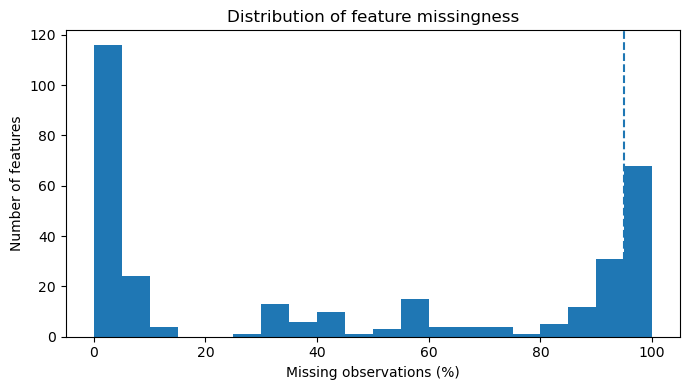

In [10]:
rates = np.array(list(missing_rates.values()))

plt.figure(figsize=(7, 4))
plt.hist(100 * rates, bins=20)
plt.axvline(100 * MISSING_THRESHOLD, linestyle="--")
plt.xlabel("Missing observations (%)")
plt.ylabel("Number of features")
plt.title("Distribution of feature missingness")
plt.tight_layout()
plt.show()


## 1.6. Remove selected columns

The removal list is determined from the training set only. The same list should later be applied unchanged to the test set.


In [11]:
features_to_remove = set(identifier_features + survey_features + constant_features + sparse_features)

keep_mask = np.array([
    name not in features_to_remove
    for name in feature_names
])

x_train_clean = x_train[:, keep_mask]
feature_names_clean = feature_names[keep_mask]
print(feature_names_clean)

print("Shape before cleaning:", x_train.shape)
print("Shape after cleaning: ", x_train_clean.shape)
print("Removed columns:", np.sum(~keep_mask))
print("Retained columns:", np.sum(keep_mask))


['PVTRESD1' 'CELLFON3' 'NUMADULT' 'NUMMEN' 'NUMWOMEN' 'CADULT' 'PVTRESD2'
 'CSTATE' 'LANDLINE' 'HHADULT' 'GENHLTH' 'PHYSHLTH' 'MENTHLTH' 'POORHLTH'
 'HLTHPLN1' 'PERSDOC2' 'MEDCOST' 'CHECKUP1' 'BPHIGH4' 'BPMEDS' 'BLOODCHO'
 'CHOLCHK' 'TOLDHI2' 'CVDSTRK3' 'ASTHMA3' 'ASTHNOW' 'CHCSCNCR' 'CHCOCNCR'
 'CHCCOPD1' 'HAVARTH3' 'ADDEPEV2' 'CHCKIDNY' 'DIABETE3' 'DIABAGE2' 'SEX'
 'MARITAL' 'EDUCA' 'RENTHOM1' 'NUMHHOL2' 'CPDEMO1' 'VETERAN3' 'EMPLOY1'
 'CHILDREN' 'INCOME2' 'INTERNET' 'WEIGHT2' 'HEIGHT3' 'PREGNANT' 'QLACTLM2'
 'USEEQUIP' 'BLIND' 'DECIDE' 'DIFFWALK' 'DIFFDRES' 'DIFFALON' 'SMOKE100'
 'SMOKDAY2' 'STOPSMK2' 'LASTSMK2' 'USENOW3' 'ALCDAY5' 'AVEDRNK2'
 'DRNK3GE5' 'MAXDRNKS' 'FRUITJU1' 'FRUIT1' 'FVBEANS' 'FVGREEN' 'FVORANG'
 'VEGETAB1' 'EXERANY2' 'EXRACT11' 'EXEROFT1' 'EXERHMM1' 'EXRACT21'
 'EXEROFT2' 'EXERHMM2' 'STRENGTH' 'LMTJOIN3' 'ARTHDIS2' 'ARTHSOCL'
 'JOINPAIN' 'SEATBELT' 'FLUSHOT6' 'FLSHTMY2' 'IMFVPLAC' 'PNEUVAC3'
 'HIVTST6' 'HIVTSTD3' 'WHRTST10' 'PDIABTST' 'PREDIAB1' 'INSULIN'
 'BLDSU

In [12]:
print("===================================")
print("FEATURE REMOVAL SUMMARY")
print("===================================")
print("Original columns:         ", len(feature_names))
print("Identifiers:              ", sum(f in feature_names for f in identifier_features))
print("Survey/admin variables:   ", sum(f in feature_names for f in survey_features))
print("Constant/empty variables: ", len(constant_features))
print(f">{100*MISSING_THRESHOLD:.0f}% missing variables:    ", len(sparse_features))
print("Unique columns removed:   ", len(features_to_remove))
print("Remaining columns:        ", len(feature_names_clean))


FEATURE REMOVAL SUMMARY
Original columns:          322
Identifiers:               3
Survey/admin variables:    17
Constant/empty variables:  6
>95% missing variables:     68
Unique columns removed:    92
Remaining columns:         230


## 1.7. Save retained and removed feature lists

To be reused in final preprocessing pipeline.

In [13]:
with open("./dataset/retained_features.txt", "w") as f:
    for name in feature_names_clean:
        f.write(name + "\n")

with open("./dataset/removed_features.txt", "w") as f:
    for name in sorted(features_to_remove):
        f.write(name + "\n")

print("Saved retained_features.txt and removed_features.txt")


Saved retained_features.txt and removed_features.txt


# 2. Feature Types and BRFSS Encoding

The BRFSS dataset contains a mixture of binary, categorical, ordinal, and continuous variables. These feature types should not be processed in the same way. Before visualizing distributions or training models, we therefore classify the retained features according to their data type and inspect special response codes such as *Don't know*, *Refused*, or *Not applicable*. These codes must be handled carefully because they do not represent ordinary numerical values.


In [14]:
def summarize_feature_types(x, names):
    summary = []

    for j, name in enumerate(names):
        column = x[:, j]

        valid = column[~np.isnan(column)]
        unique_values = np.unique(valid)

        summary.append({
            "name": name,
            "n_unique": len(unique_values),
            "min": np.min(valid) if len(valid) > 0 else np.nan,
            "max": np.max(valid) if len(valid) > 0 else np.nan,
            "unique_values": unique_values[:20]
        })

    return summary


feature_summary = summarize_feature_types(
    x_train_clean,
    feature_names_clean
)

for feature in feature_summary:
    print(
        feature["name"],
        "| unique:", feature["n_unique"],
        "| range:", feature["min"], "-", feature["max"],
        "| values:", feature["unique_values"]
    )

PVTRESD1 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
CELLFON3 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
NUMADULT | unique: 16 | range: 1.0 - 20.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 14. 15. 18. 20.]
NUMMEN | unique: 12 | range: 0.0 - 18.0 | values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 18.]
NUMWOMEN | unique: 11 | range: 0.0 - 10.0 | values: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
CADULT | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
PVTRESD2 | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
CSTATE | unique: 2 | range: 1.0 - 2.0 | values: [1. 2.]
LANDLINE | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
HHADULT | unique: 25 | range: 1.0 - 99.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 18. 20. 21.
 22. 23.]
GENHLTH | unique: 7 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 5. 7. 9.]
PHYSHLTH | unique: 33 | range: 1.0 - 99.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19

## Analysis of Selected Health and Lifestyle Features

Because the dataset contains a very large number of variables, analyzing
every feature individually would be impractical. We therefore selected a
small set of representative variables related to demographics, general
health, cardiovascular risk factors, lifestyle, and socioeconomic status.

The goal of this analysis is to understand how the main types of variables
are encoded, identify special BRFSS response codes, and investigate their
relationship with the target `_MICHD`.

In [15]:
focus_features = [
    "_AGEG5YR",   # age group
    "GENHLTH",    # general health
    "_BMI5",      # BMI
    "_BMI5CAT",   # BMI category
    "SMOKE100",   # ever smoked 100 cigarettes
    "SMOKDAY2",   # current smoking frequency
    "DIABETE3",   # diabetes
    "BPHIGH4",    # high blood pressure
    "TOLDHI2",    # high cholesterol
    "CVDSTRK3",   # previous stroke
    "EXERANY2",   # physical activity
    "EDUCA",      # education
    "INCOME2",    # income
    "SEX",        # sex
    "MEDCOST",    # unable to see doctor because of cost
]

for f in focus_features:
    feature = next((fs for fs in feature_summary if fs["name"] == f), None)
    print(
        feature["name"],
        "| unique:", feature["n_unique"],
        "| range:", feature["min"], "-", feature["max"],
        "| values:", feature["unique_values"]
    )

_AGEG5YR | unique: 14 | range: 1.0 - 14.0 | values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]
GENHLTH | unique: 7 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 5. 7. 9.]
_BMI5 | unique: 3524 | range: 12.02 - 97.65 | values: [12.02 12.05 12.11 12.15 12.16 12.17 12.2  12.21 12.22 12.33 12.37 12.45
 12.48 12.53 12.55 12.56 12.63 12.69 12.7  12.71]
_BMI5CAT | unique: 4 | range: 1.0 - 4.0 | values: [1. 2. 3. 4.]
SMOKE100 | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
SMOKDAY2 | unique: 5 | range: 1.0 - 9.0 | values: [1. 2. 3. 7. 9.]
DIABETE3 | unique: 6 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 7. 9.]
BPHIGH4 | unique: 6 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 7. 9.]
TOLDHI2 | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
CVDSTRK3 | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
EXERANY2 | unique: 4 | range: 1.0 - 9.0 | values: [1. 2. 7. 9.]
EDUCA | unique: 7 | range: 1.0 - 9.0 | values: [1. 2. 3. 4. 5. 6. 9.]
INCOME2 | unique: 10 | range: 1.0 - 99.0 | val

After examining how these features are encoded using the BRFSS codebook, we classify them into four types: **binary, categorical, ordinal, and continuous**.

In [16]:
feature_types = {
    "_AGEG5YR": "ordinal",
    "GENHLTH": "ordinal",
    "_BMI5": "continuous",
    "_BMI5CAT": "ordinal",
    "SMOKE100": "binary",
    "SMOKDAY2": "categorical",
    "DIABETE3": "categorical",
    "BPHIGH4": "categorical",
    "TOLDHI2": "binary",
    "CVDSTRK3": "binary",
    "EXERANY2": "binary",
    "EDUCA": "ordinal",
    "INCOME2": "ordinal",
    "SEX": "binary",
    "MEDCOST": "binary",
}

special_codes = {
    "_AGEG5YR": [14],
    "GENHLTH": [7, 9],
    "SMOKE100": [7, 9],
    "SMOKDAY2": [7, 9],
    "DIABETE3": [7, 9],
    "BPHIGH4": [7, 9],
    "TOLDHI2": [7, 9],
    "CVDSTRK3": [7, 9],
    "EXERANY2": [7, 9],
    "EDUCA": [9],
    "INCOME2": [77, 99],
    "MEDCOST": [7, 9],
}

# Clean these variables for the EDA wihtout modifying the original training data. 
x_eda = x_train_clean.copy()

for feature, codes in special_codes.items():

    if feature not in feature_names_clean:
        continue

    j = np.where(feature_names_clean == feature)[0][0]

    for code in codes:
        x_eda[x_eda[:, j] == code, j] = np.nan

# Fix BMI
bmi_idx = np.where(feature_names_clean == "_BMI5")[0][0]

# Convert from stored integer representation to real BMI.
x_eda[:, bmi_idx] = x_eda[:, bmi_idx] / 100

In [17]:
for feature in focus_features:

    if feature not in feature_names_clean:
        print(feature, "was removed previously")
        continue

    j = np.where(feature_names_clean == feature)[0][0]
    column = x_eda[:, j]

    valid = column[~np.isnan(column)]

    print("\n", feature)
    print("Number valid:", len(valid))
    print("Missing:", np.sum(np.isnan(column)))
    print("Unique values:", len(np.unique(valid)))

    if len(np.unique(valid)) <= 20:
        print("Values:", np.unique(valid))


 _AGEG5YR
Number valid: 324192
Missing: 3943
Unique values: 13
Values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]

 GENHLTH
Number valid: 327247
Missing: 888
Unique values: 5
Values: [1. 2. 3. 4. 5.]

 _BMI5
Number valid: 301062
Missing: 27073
Unique values: 3524

 _BMI5CAT
Number valid: 301062
Missing: 27073
Unique values: 4
Values: [1. 2. 3. 4.]

 SMOKE100
Number valid: 315185
Missing: 12950
Unique values: 2
Values: [1. 2.]

 SMOKDAY2
Number valid: 136512
Missing: 191623
Unique values: 3
Values: [1. 2. 3.]

 DIABETE3
Number valid: 327656
Missing: 479
Unique values: 4
Values: [1. 2. 3. 4.]

 BPHIGH4
Number valid: 327217
Missing: 918
Unique values: 4
Values: [1. 2. 3. 4.]

 TOLDHI2
Number valid: 281811
Missing: 46324
Unique values: 2
Values: [1. 2.]

 CVDSTRK3
Number valid: 327398
Missing: 737
Unique values: 2
Values: [1. 2.]

 EXERANY2
Number valid: 300068
Missing: 28067
Unique values: 2
Values: [1. 2.]

 EDUCA
Number valid: 326863
Missing: 1272
Unique values: 6
Values: [1

Inspecting Feature Values

We inspect the number of valid observations, missing values, and unique values for the selected features. This step verifies that the BRFSS special codes were handled correctly and helps determine how each variable should be processed. For example, _BMI5 behaves as a continuous feature, while variables such as GENHLTH, EDUCA, and _AGEG5YR contain a small number of ordered categories. The inspection also reveals features with substantial missingness, such as SMOKDAY2, which require particular attention during preprocessing.

# Relationship with MICHD

To investigate whether the selected features contain useful predictive information, we compare the proportion of positive MICHD cases across their different categories. The plots below show how MICHD prevalence varies with age, general health, diabetes status, high blood pressure, and previous stroke.

In [18]:
def target_rate_by_category(x, y, names, feature):

    j = np.where(names == feature)[0][0]

    column = x[:, j]
    valid = ~np.isnan(column)

    x_valid = column[valid]
    y_valid = y[valid]

    categories = np.unique(x_valid)

    rates = []
    counts = []

    for category in categories:

        mask = x_valid == category

        rates.append(
            np.mean(y_valid[mask] == 1)
        )

        counts.append(np.sum(mask))

    return categories, np.array(rates), np.array(counts)

In [19]:
def plot_target_rate(x, y, names, feature):

    categories, rates, counts = target_rate_by_category(
        x, y, names, feature
    )

    plt.figure(figsize=(7, 4))

    plt.bar(
        categories.astype(str),
        rates
    )

    plt.xlabel(feature)
    plt.ylabel("MICHD positive rate")
    plt.title(f"MICHD prevalence by {feature}")

    plt.tight_layout()
    plt.show()

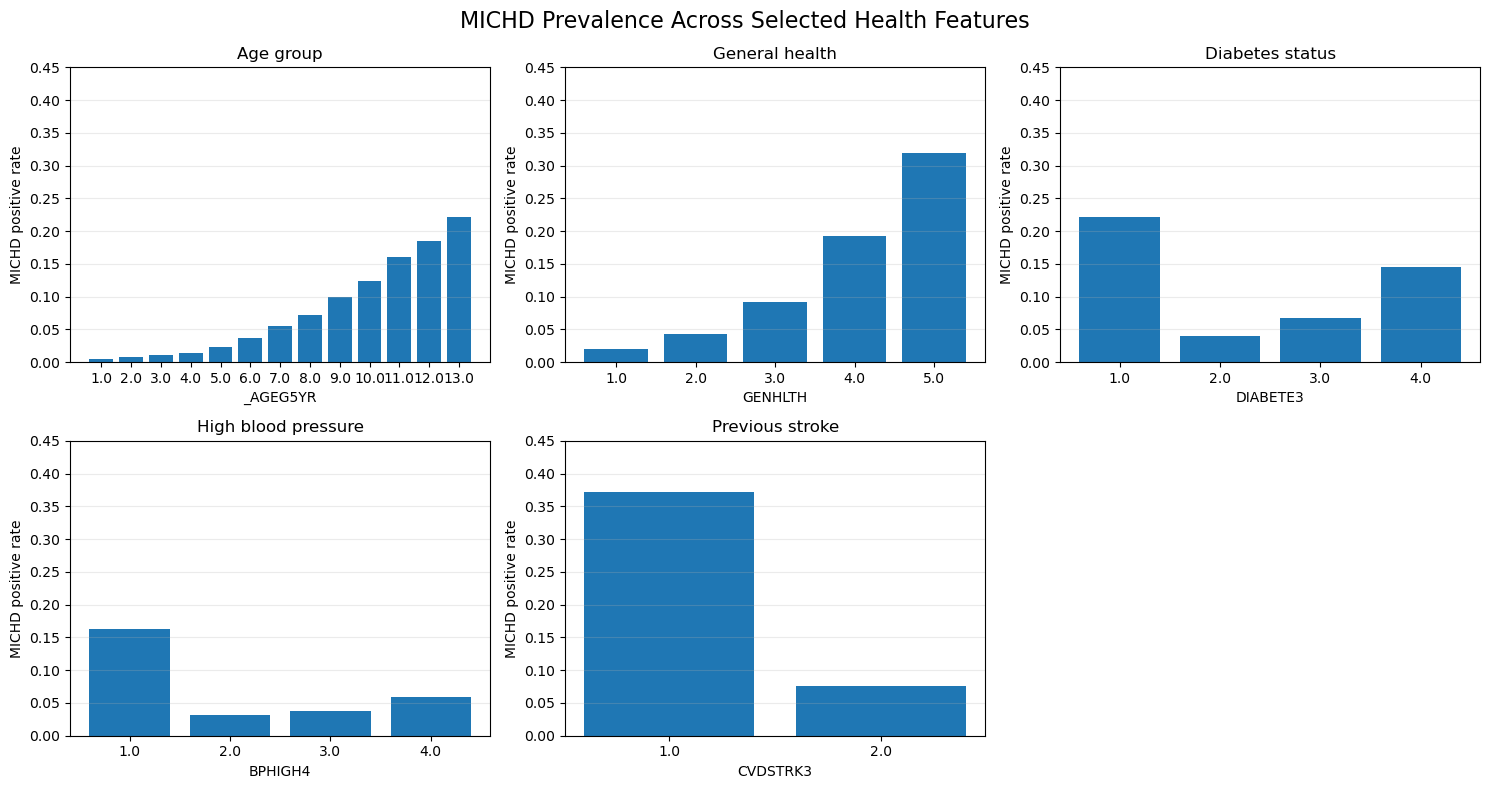

In [20]:
def plot_target_rate_subplot(x, y, names, feature, ax, title=None):
    categories, rates, counts = target_rate_by_category(
        x, y, names, feature
    )

    ax.bar(
        categories.astype(str),
        rates
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("MICHD positive rate")
    ax.set_title(title if title else feature)

    # Same y-axis scale makes comparisons easier
    ax.set_ylim(0, 0.45)

    ax.grid(axis="y", alpha=0.25)

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 8)
)

features = [
    ("_AGEG5YR", "Age group"),
    ("GENHLTH", "General health"),
    ("DIABETE3", "Diabetes status"),
    ("BPHIGH4", "High blood pressure"),
    ("CVDSTRK3", "Previous stroke"),
]

axes = axes.flatten()

for ax, (feature, title) in zip(axes, features):
    plot_target_rate_subplot(
        x_eda,
        y_train,
        feature_names_clean,
        feature,
        ax,
        title
    )

# We only have 5 plots, so hide the empty 6th subplot
axes[-1].axis("off")

fig.suptitle(
    "MICHD Prevalence Across Selected Health Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### BMI Analysis

We examine BMI both as a continuous variable and through the derived BMI categories. The first plot shows the overall BMI distribution, while the second compares MICHD prevalence across BMI categories. This allows us to study both the shape of the variable and its relationship with the target.

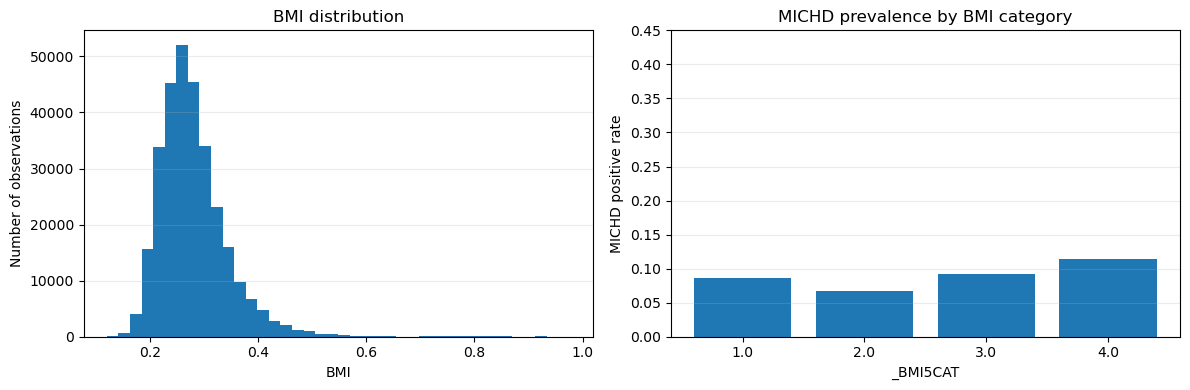

In [21]:
bmi_idx = np.where(
    feature_names_clean == "_BMI5"
)[0][0]

bmi = x_eda[:, bmi_idx]

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

# BMI distribution
axes[0].hist(
    bmi[~np.isnan(bmi)],
    bins=40
)

axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Number of observations")
axes[0].set_title("BMI distribution")
axes[0].grid(axis="y", alpha=0.25)


# MICHD rate by BMI category
plot_target_rate_subplot(
    x_eda,
    y_train,
    feature_names_clean,
    "_BMI5CAT",
    axes[1],
    title="MICHD prevalence by BMI category"
)

plt.tight_layout()
plt.show()

### Observations
Several features show clear associations with the target. MICHD prevalence
increases substantially across age groups and as self-reported general
health worsens. Respondents reporting diabetes, high blood pressure,
high cholesterol, or a previous stroke also show higher MICHD prevalence.

These results indicate that the dataset contains meaningful predictive
structure and that both categorical and continuous health variables should
be considered during modeling.